# Performance comparison

In [24]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
from pytorch_lightning.loggers import CSVLogger
import segmentation_models_pytorch as smp
from datasets import load_dataset
from torchvision.transforms import v2
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import cv2
import glob
from PIL import Image
from scipy.ndimage import distance_transform_edt

pl.seed_everything(42)

Seed set to 42


42

In [25]:
def sprinkles(
    img,
    size,
    perc,
    channels=3,
    mode="random",
    width=2,
    pattern_path="fence_pattern.png",
    mask_dataset_path="dataset/Training Set/Training_Labels",
    dilation_kernel_size=3,
    background_weight=0.1,
    normalize_weights=True,
):
    """
    img: torch.Tensor of shape (C, H, W), values in [0, 1]
    mode: "random" | "grid" | "diagonals" | "pattern" | "dataset_mask"
    size:
        - random: sprinkle square size
        - grid/diagonals: spacing between lines
        - pattern/dataset_mask: ignored
    perc:
        - random: percentage of pixels to affect
        - grid/diagonals/pattern/dataset_mask: ignored (kept for API consistency)
    width: line thickness for grid/diagonals
    pattern_path: path to the fence pattern image (for mode="pattern")
    mask_dataset_path: path to the mask dataset folder (for mode="dataset_mask")
    dilation_kernel_size: kernel size for morphological dilation (for mode="dataset_mask")
    """
    x = img.clone()
    C, H, W = x.shape
    mask = torch.zeros((1, H, W), dtype=torch.float32)
    
    # RANDOM (original behavior)
    if mode == "random":
        number_of_pixels_to_change = int(perc * H * W)
        number_of_sprinkles = max(1, number_of_pixels_to_change // (size * size))
        for _ in range(number_of_sprinkles):
            y = torch.randint(0, H - size, (1,)).item()
            x0 = torch.randint(0, W - size, (1,)).item()
            x[:, y:y + size, x0:x0 + size] = 0.0
            mask[:, y:y + size, x0:x0 + size] = 1.0
    
    # GRID (vertical + horizontal lines)
    elif mode == "grid":
        for y in range(0, H, size):
            y_end = min(y + width, H)
            x[:, y:y_end, :] = 0.0
            mask[:, y:y_end, :] = 1.0
        for x0 in range(0, W, size):
            x_end = min(x0 + width, W)
            x[:, :, x0:x_end] = 0.0
            mask[:, :, x0:x_end] = 1.0
    
    # DIAGONALS (both directions)
    elif mode == "diagonals":
        for offset in range(-H, W, size):
            for w in range(width):
                # main diagonal \
                y = torch.arange(H)
                x_diag = y + offset + w
                valid = (x_diag >= 0) & (x_diag < W)
                x[:, y[valid], x_diag[valid]] = 0.0
                mask[:, y[valid], x_diag[valid]] = 1.0
                # anti-diagonal /
                x_anti = (W - 1 - y) + offset + w
                valid = (x_anti >= 0) & (x_anti < W)
                x[:, y[valid], x_anti[valid]] = 0.0
                mask[:, y[valid], x_anti[valid]] = 1.0
    
    # PATTERN (load from image file)
    elif mode == "pattern":
        # Load the pattern image
        if not os.path.exists(pattern_path):
            raise FileNotFoundError(f"Pattern image not found: {pattern_path}")
        
        pattern_img = Image.open(pattern_path).convert("L")  # Convert to grayscale
        pattern_img = pattern_img.resize((W, H), Image.NEAREST)  # Resize to match image
        
        # Convert to tensor and normalize
        pattern_array = np.array(pattern_img, dtype=np.float32) / 255.0
        pattern_tensor = torch.from_numpy(pattern_array).unsqueeze(0)  # [1, H, W]
        
        # Binarize the pattern (threshold at 0.5)
        mask = (pattern_tensor > 0.5).float()
        
        # Apply mask to image (zero out where mask is 1)
        x = x * (1 - mask)
    
    # DATASET_MASK (load random mask from dataset)
    elif mode == "dataset_mask":
        # Get all mask files from the dataset
        if not os.path.exists(mask_dataset_path):
            raise FileNotFoundError(f"Mask dataset path not found: {mask_dataset_path}")
        
        mask_files = glob.glob(os.path.join(mask_dataset_path, "*.png")) + \
                     glob.glob(os.path.join(mask_dataset_path, "*.jpg")) + \
                     glob.glob(os.path.join(mask_dataset_path, "*.jpeg"))
        
        if len(mask_files) == 0:
            raise FileNotFoundError(f"No mask images found in: {mask_dataset_path}")
        
        # Randomly select a mask file
        random_mask_path = np.random.choice(mask_files)
        
        # Load the mask image
        mask_img = Image.open(random_mask_path).convert("L")  # Convert to grayscale
        mask_array = np.array(mask_img, dtype=np.float32) / 255.0
        
        # Get mask dimensions
        mask_h, mask_w = mask_array.shape
        
        # Strategy: Random crop or resize based on relative sizes
        
        mask_img_resized = mask_img.resize((W, H), Image.BILINEAR)
        mask_array = np.array(mask_img_resized, dtype=np.float32) / 255.0
        
        # Apply dilation to thicken the mask lines
        if dilation_kernel_size > 0:
            kernel = cv2.getStructuringElement(
                cv2.MORPH_ELLIPSE, 
                (dilation_kernel_size, dilation_kernel_size)
            )
            mask_array = cv2.dilate(mask_array, kernel, iterations=1)
        
        # Convert to tensor
        mask_tensor = torch.from_numpy(mask_array).unsqueeze(0)  # [1, H, W]
        
        # Binarize the mask (threshold at 0.5)
        mask = (mask_tensor > 0.5).float()
        
        # Apply mask to image (zero out where mask is 1)
        x = x * (1 - mask)
    
    else:
        raise ValueError(f"Unknown mode: {mode}")
        
    weights = torch.full((1, H, W), background_weight, dtype=torch.float32)
    mask_np = mask[0].numpy().astype(bool)
    
    if mask_np.any():  # Solo si hay áreas afectadas
        # Distance transform: calcula distancia al borde más cercano
        # Para las áreas enmascaradas (True), da valores más altos en el centro
        distances = distance_transform_edt(mask_np)
        distances = torch.from_numpy(distances).float().unsqueeze(0)
        
        # Normalizar distancias si se requiere
        if normalize_weights and distances.max() > 0:
            distances = distances / distances.max()
        
        # Aplicar las distancias solo donde hay mask
        weights = torch.where(mask > 0, distances, weights)

    
    return x, img, mask, weights

In [26]:
class HFImageDataset(Dataset):
    def __init__(self, hf_dataset, transforms=None, sprinkles_mode='mixed'):
        self.dataset = hf_dataset
        self.transforms = transforms
        self.sprinkles_mode = sprinkles_mode
        self.modes = ['random', 'grid', 'diagonals', 'dataset_mask']
    
    def __len__(self): return len(self.dataset)
    
    def __getitem__(self, idx):
        image = self.dataset[idx]['image']
        if self.transforms: image = self.transforms(image)
        # Seleccionar modo aleatorio si es mixed
        mode = np.random.choice(self.modes) if self.sprinkles_mode == 'mixed' else self.sprinkles_mode
        masked, original, mask, weights = sprinkles(image, size=10, perc=0.15, mode=mode)
        return {'masked_image': masked, 'original_image': original, 'mask': mask, 'weights': weights}

class DataModule(pl.LightningDataModule):
    def __init__(self, dataset_name, bs=32, sprinkles_mode='mixed'):
        super().__init__()
        self.dataset_name = dataset_name
        self.bs = bs
        self.sprinkles_mode = sprinkles_mode

    def setup(self, stage=None):
        ds = load_dataset(self.dataset_name)['train']
        train_size = int(0.85 * len(ds))
        train_data, val_data = random_split(ds, [train_size, len(ds) - train_size])
        
        # Pipeline de Augmentation (Training)
        self.train_aug = v2.Compose([
            v2.ToImage(), v2.Resize(256), v2.CenterCrop(224),
            v2.RandomHorizontalFlip(p=0.5),
            v2.ColorJitter(brightness=0.2, contrast=0.2),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(mean=[0.344, 0.380, 0.407], std=[0.202, 0.136, 0.115])
        ])
        
        # Pipeline de Test (Sin aleatoriedad)
        self.test_transforms = v2.Compose([
            v2.ToImage(), v2.Resize(256), v2.CenterCrop(224),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(mean=[0.344, 0.380, 0.407], std=[0.202, 0.136, 0.115])
        ])
        
        self.train_ds = HFImageDataset(train_data, transforms=self.train_aug, sprinkles_mode=self.sprinkles_mode)
        self.valid_ds = HFImageDataset(val_data, transforms=self.test_transforms, sprinkles_mode=self.sprinkles_mode)

    def train_dataloader(self): return DataLoader(self.train_ds, batch_size=self.bs, shuffle=True, num_workers=4)
    def val_dataloader(self): return DataLoader(self.valid_ds, batch_size=self.bs, num_workers=4)

In [27]:
class LightningModule(pl.LightningModule):
    def __init__(self, learning_rate=3e-4):
        super().__init__()
        self.save_hyperparameters()
        # 4 canales de entrada (RGB + Máscara)
        self.model = smp.Unet(encoder_name='resnet50', encoder_weights='imagenet', in_channels=4, classes=3)
        self.training_step_outputs = defaultdict(float)
        self.validation_step_outputs = defaultdict(float)
        
    def forward(self, x): return self.model(x)

    def _shared_step(self, batch):
        x_img, y, mask, weights = batch['masked_image'], batch['original_image'], batch['mask'], batch['weights']
        # Concatenar imagen y máscara
        x_input = torch.cat([x_img, mask], dim=1)
        y_hat = self(x_input)
        
        # Weighted L1 Loss: penaliza más el error donde la valla es gruesa
        loss_pixel = F.l1_loss(y_hat, y, reduction='none')
        loss = (loss_pixel * weights.expand_as(loss_pixel)).sum() / (weights.sum() + 1e-8)
        return loss

    def training_step(self, batch, batch_idx):
        loss = self._shared_step(batch)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        self.training_step_outputs['loss'] += loss.detach().cpu(); self.training_step_outputs['steps'] += 1
        return loss
    
    def validation_step(self, batch, batch_idx):
        loss = self._shared_step(batch)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.validation_step_outputs['loss'] += loss.detach().cpu(); self.validation_step_outputs['steps'] += 1
        return loss

    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sch, "monitor": "val_loss"}}

In [28]:
import cv2
from skimage.morphology import dilation as sk_dilation
from skimage.morphology import disk

class DefencingInferenceDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transforms=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transforms = transforms
        self.image_files = sorted([f for f in os.listdir(images_dir) if f.lower().endswith(".jpg")])
    
    def __len__(self): return len(self.image_files)
    
    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        base_name = os.path.splitext(img_name)[0]
        
        # Cargar imagen real y máscara
        image_pil = Image.open(os.path.join(self.images_dir, img_name)).convert("RGB")
        mask_pil = Image.open(os.path.join(self.labels_dir, base_name + ".png")).convert("L")
        
        # Aplicar transforms (Resize a 256, Crop a 224, Normalize)
        if self.transforms:
            # Importante: para v2, pasamos ambos para que el crop sea idéntico
            image_t, mask_t = self.transforms(image_pil, mask_pil)

        # Convertir máscara a numpy para dilatación con OpenCV (más estable)
        # mask_t es [1, 224, 224]
        mask_np = mask_t[0].numpy() 
        
        # Dilatación con OpenCV: Kernel circular de 5x5 (equivale a radio 2-3)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask_dilated = cv2.dilate(mask_np, kernel, iterations=1)
        
        # Convertir de nuevo a tensor [1, 224, 224]
        mask_final = torch.from_numpy(mask_dilated).unsqueeze(0).float()
        mask_final = (mask_final > 0.5).float() # Binarizar
        
        # Preparar entrada para el modelo (Imagen con valla en negro)
        masked_input = image_t * (1 - mask_final)
        
        return {
            'masked_image': masked_input, 
            'original_image': image_t, 
            'mask': mask_final,
            'filename': img_name
        }
        

In [29]:
import os
import torch
import torch.nn.functional as F
import pandas as pd
from tqdm import tqdm

def export_named_checkpoints_to_csv(checkpoint_dir, dm, output_file="checkpoint_comparison.csv", device="cuda"):
    """
    checkpoint_dir: Path to the folder containing your named .ckpt files.
    dm: Your initialized DataModule.
    """
    # Setup the validation dataloader from your DataModule
    dm.setup(stage='fit')
    val_loader = dm.val_dataloader()
    
    results = []
    
    # List all checkpoint files in the specified folder
    # This will pick up any .ckpt file inside the 'checkpoints' folder
    ckpt_files = [f for f in os.listdir(checkpoint_dir) if f.endswith(".ckpt")]

    if not ckpt_files:
        print(f"No .ckpt files found in {checkpoint_dir}")
        return None

    for ckpt_name in tqdm(ckpt_files, desc="Evaluating Checkpoints"):
        ckpt_path = os.path.join(checkpoint_dir, ckpt_name)

        try:
            # Load the model using your LightningModule definition
            # It automatically handles the 4-channel U-Net architecture
            model = LightningModule.load_from_checkpoint(ckpt_path).to(device)
            model.eval()
            
            total_mse = 0.0
            total_pixels = 0
            
            with torch.no_grad():
                for batch in val_loader:
                    # Extract data from the validation batch
                    x_img = batch['masked_image'].to(device)
                    y_real = batch['original_image'].to(device)
                    mask = batch['mask'].to(device)
                    
                    # Concatenate RGB image and mask for the 4-channel input
                    x_input = torch.cat([x_img, mask], dim=1)
                    y_hat = model(x_input)
                    
                    # Calculate MSE across all pixels in the batch
                    batch_mse = F.mse_loss(y_hat, y_real, reduction='sum')
                    
                    total_mse += batch_mse.item()
                    total_pixels += y_real.numel() 
            
            final_mse = total_mse / total_pixels
            
            results.append({
                "Checkpoint_Name": ckpt_name,
                "Validation_MSE": final_mse
            })
            
        except Exception as e:
            print(f"Error processing {ckpt_name}: {str(e)}")

    # Create DataFrame, sort by performance, and save to CSV
    df = pd.DataFrame(results)
    df = df.sort_values(by="Validation_MSE", ascending=True)
    df.to_csv(output_file, index=False)
    
    print(f"\nEvaluation complete. Results saved to {output_file}")
    return df

# --- How to run ---
checkpoint_path = "checkpoints" # Your specific folder name
dm = DataModule(dataset_name="urbanstevie/reference_dataset", bs=32, sprinkles_mode="mixed")
results_df = export_named_checkpoints_to_csv(checkpoint_path, dm)

Repo card metadata block was not found. Setting CardData to empty.
Evaluating Checkpoints: 100%|██████████| 4/4 [02:05<00:00, 31.30s/it]


Evaluation complete. Results saved to checkpoint_comparison.csv


In [30]:
results_df.to_csv('comparison.csv', index=False)
print("\nSuccess! Comparison saved to comparison.csv")


Success! Comparison saved to comparison.csv


In [ ]:
import os
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from torch.utils.data import DataLoader

# --- Configuration ---
CHECKPOINT_DIR = "checkpoints"
OUTPUT_CSV = "checkpoint_comparison.csv"
NUM_TEST_IMAGES = 4  # Number of images to show in visual comparison
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def denormalize(tensor, mean=[0.344, 0.380, 0.407], std=[0.202, 0.136, 0.115]):
    """Reverses the normalization for visualization."""
    m = torch.tensor(mean).view(3, 1, 1)
    s = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(tensor * s + m, 0, 1)

def run_full_comparison():
    # 1. Setup Data
    dm = DataModule(dataset_name="urbanstevie/reference_dataset", bs=32, sprinkles_mode="mixed")
    dm.setup(stage='fit')
    val_loader = dm.val_dataloader()

    inference_ds = DefencingInferenceDataset(
        images_dir="dataset/Test Set/Test_Images",
        labels_dir="dataset/Test Set/Test_Labels",
        transforms=dm.test_transforms
    )
    inference_loader = DataLoader(inference_ds, batch_size=NUM_TEST_IMAGES, shuffle=False)
    test_batch = next(iter(inference_loader)) # Get a fixed batch for visual comparison

    # 2. Iterate through Checkpoints
    results = []
    visual_outputs = {} # Stores {model_name: [images]}
    
    ckpt_files = sorted([f for f in os.listdir(CHECKPOINT_DIR) if f.endswith(".ckpt")])
    
    for ckpt_name in tqdm(ckpt_files, desc="Processing Checkpoints"):
        path = os.path.join(CHECKPOINT_DIR, ckpt_name)
        model_label = ckpt_name.replace(".ckpt", "")
        
        try:
            model = LightningModule.load_from_checkpoint(path).to(DEVICE)
            model.eval()

            # --- MSE CALCULATION ---
            total_mse, total_pixels = 0.0, 0
            with torch.no_grad():
                for batch in val_loader:
                    x_in = torch.cat([batch['masked_image'], batch['mask']], dim=1).to(DEVICE)
                    y_hat = model(x_in)
                    mse = F.mse_loss(y_hat, batch['original_image'].to(DEVICE), reduction='sum')
                    total_mse += mse.item()
                    total_pixels += batch['original_image'].numel()
            
            avg_mse = total_mse / total_pixels
            results.append({"Model": model_label, "Val_MSE": avg_mse})

            # --- VISUAL INFERENCE ---
            with torch.no_grad():
                x_test = test_batch['masked_image'].to(DEVICE)
                mask_test = test_batch['mask'].to(DEVICE)
                y_real = test_batch['original_image'].to(DEVICE)
                
                y_pred = model(torch.cat([x_test, mask_test], dim=1))
                # Blending: Original image outside mask + Prediction inside mask
                final_res = y_real * (1 - mask_test) + y_pred * mask_test
                visual_outputs[model_label] = final_res.cpu()

        except Exception as e:
            print(f"Error loading {ckpt_name}: {e}")

    # 3. Save and Plot Metrics
    df = pd.DataFrame(results).sort_values("Val_MSE")
    df.to_csv(OUTPUT_CSV, index=False)

    # Plot 1: MSE Comparison
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x="Val_MSE", y="Model", palette="magma")
    plt.title("Performance Comparison (Lower is Better)")
    plt.xlabel("Validation MSE")
    plt.savefig("performance_plot.png")
    plt.show()

    # Plot 2: Visual Comparison Grid
    num_models = len(visual_outputs)
    fig, axes = plt.subplots(NUM_TEST_IMAGES, num_models + 1, figsize=(4 * (num_models + 1), 4 * NUM_TEST_IMAGES))
    
    for i in range(NUM_TEST_IMAGES):
        # Column 0: Original image with fence
        # (We show the masked_image here to see what the model actually received)
        input_img = denormalize(test_batch['masked_image'][i]).permute(1, 2, 0).numpy()
        axes[i, 0].imshow(input_img)
        if i == 0: axes[i, 0].set_title("Input (Masked)", fontsize=12)
        axes[i, 0].axis('off')

        # Other Columns: Model Results
        for j, (name, outputs) in enumerate(visual_outputs.items()):
            res_img = denormalize(outputs[i]).permute(1, 2, 0).numpy()
            axes[i, j+1].imshow(res_img)
            if i == 0: axes[i, j+1].set_title(name, fontsize=12)
            axes[i, j+1].axis('off')

    plt.tight_layout()
    plt.savefig("visual_comparison_grid.png")
    plt.show()

# Run the process
run_full_comparison()

Repo card metadata block was not found. Setting CardData to empty.
Processing Checkpoints:   0%|          | 0/4 [00:20<?, ?it/s]


KeyboardInterrupt: 

Repo card metadata block was not found. Setting CardData to empty.
Processing Checkpoints: 100%|██████████| 4/4 [02:17<00:00, 34.44s/it]
/tmp/ipykernel_172694/3840648659.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Val_MSE", y="Model", palette="magma")


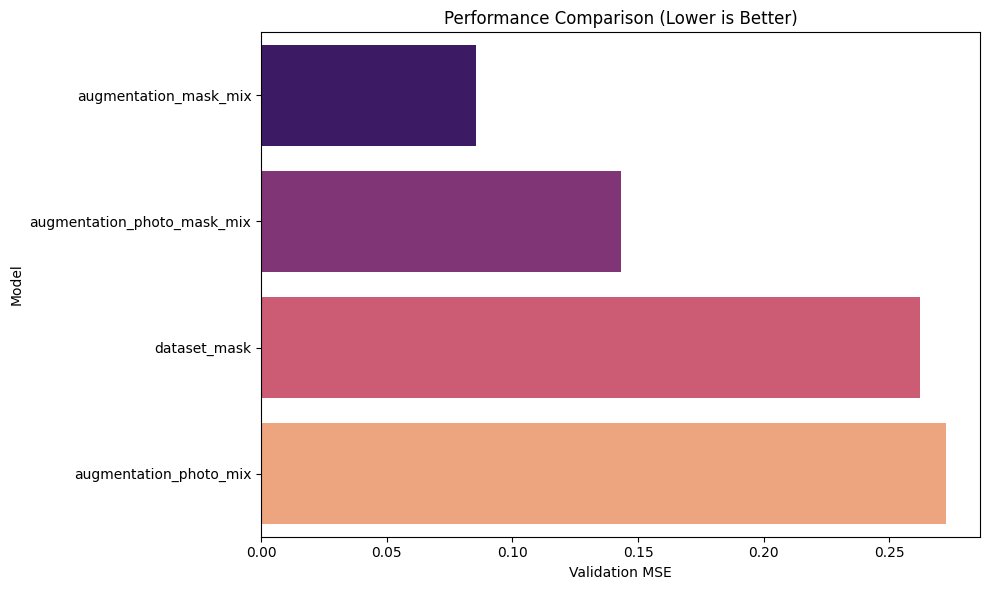

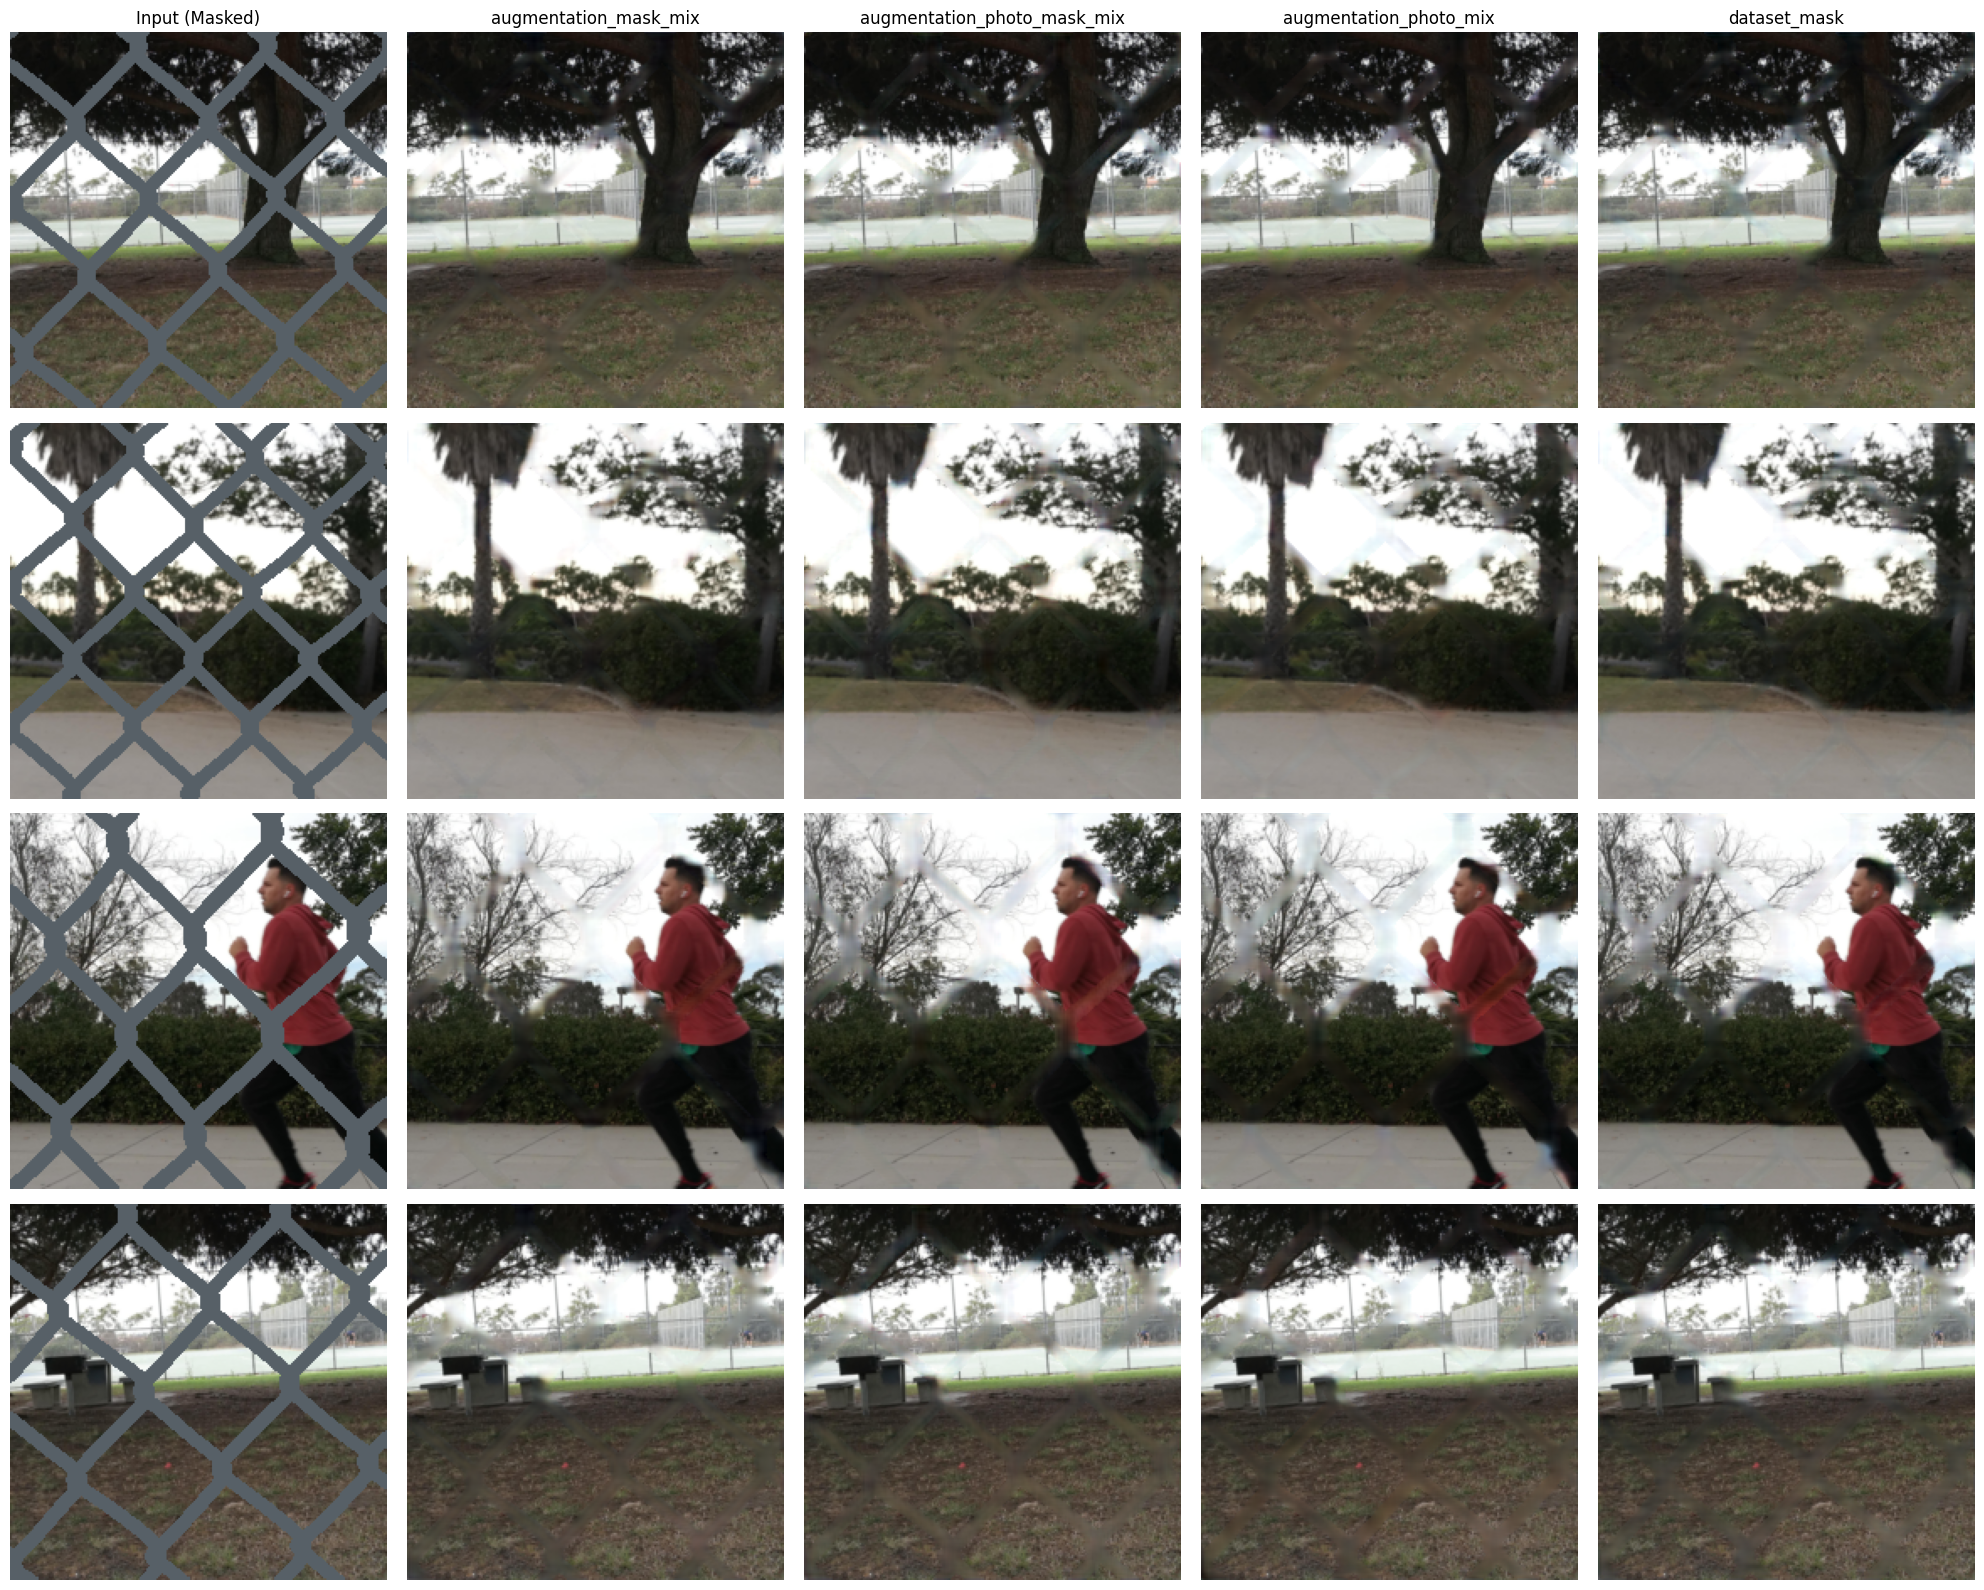

In [36]:
import os
import random
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from torch.utils.data import DataLoader, Subset

# --- Configuration ---
CHECKPOINT_DIR = "checkpoints"
OUTPUT_CSV = "checkpoint_comparison.csv"
NUM_TEST_IMAGES = 4  # Number of images to show in visual comparison
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(45)

def denormalize(tensor, mean=[0.344, 0.380, 0.407], std=[0.202, 0.136, 0.115]):
    """Reverses the normalization for visualization."""
    m = torch.tensor(mean).view(3, 1, 1)
    s = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(tensor * s + m, 0, 1)


def run_full_comparison():
    # 1. Setup Data
    dm = DataModule(dataset_name="urbanstevie/reference_dataset", bs=32, sprinkles_mode="mixed")
    dm.setup(stage="fit")
    val_loader = dm.val_dataloader()

    inference_ds = DefencingInferenceDataset(
        images_dir="dataset/Test Set/Test_Images",
        labels_dir="dataset/Test Set/Test_Labels",
        transforms=dm.test_transforms
    )

    # ----------------------------------------------------
    # RANDOM SAMPLE SELECTION (fixed across all checkpoints)
    # ----------------------------------------------------
    num_samples = len(inference_ds)
    random_indices = random.sample(range(num_samples), NUM_TEST_IMAGES)

    subset = Subset(inference_ds, random_indices)
    inference_loader = DataLoader(subset, batch_size=NUM_TEST_IMAGES, shuffle=False)
    test_batch = next(iter(inference_loader))

    # 2. Iterate through Checkpoints
    results = []
    visual_outputs = {}

    ckpt_files = sorted([f for f in os.listdir(CHECKPOINT_DIR) if f.endswith(".ckpt")])

    for ckpt_name in tqdm(ckpt_files, desc="Processing Checkpoints"):
        path = os.path.join(CHECKPOINT_DIR, ckpt_name)
        model_label = ckpt_name.replace(".ckpt", "")

        try:
            model = LightningModule.load_from_checkpoint(path).to(DEVICE)
            model.eval()

            # --------------------
            # Validation MSE
            # --------------------
            total_mse, total_pixels = 0.0, 0

            with torch.no_grad():
                for batch in val_loader:
                    x_in = torch.cat(
                        [batch["masked_image"], batch["mask"]], dim=1
                    ).to(DEVICE)

                    y_hat = model(x_in)
                    y_gt = batch["original_image"].to(DEVICE)

                    mse = F.mse_loss(y_hat, y_gt, reduction="sum")
                    total_mse += mse.item()
                    total_pixels += y_gt.numel()

            avg_mse = total_mse / total_pixels
            results.append({"Model": model_label, "Val_MSE": avg_mse})

            # --------------------
            # Visual inference
            # --------------------
            with torch.no_grad():
                x_test = test_batch["masked_image"].to(DEVICE)
                mask_test = test_batch["mask"].to(DEVICE)
                y_real = test_batch["original_image"].to(DEVICE)

                y_pred = model(torch.cat([x_test, mask_test], dim=1))

                # Blend prediction inside mask
                final_res = y_real * (1 - mask_test) + y_pred * mask_test
                visual_outputs[model_label] = final_res.cpu()

        except Exception as e:
            print(f"Error loading {ckpt_name}: {e}")

    # 3. Save metrics
    df = pd.DataFrame(results).sort_values("Val_MSE")
    df.to_csv(OUTPUT_CSV, index=False)

    # --------------------
    # Plot 1: MSE bar chart
    # --------------------
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x="Val_MSE", y="Model", palette="magma")
    plt.title("Performance Comparison (Lower is Better)")
    plt.xlabel("Validation MSE")
    plt.tight_layout()
    plt.savefig("performance_plot.png")
    plt.show()

    # --------------------
    # Plot 2: Visual comparison grid
    # --------------------
    num_models = len(visual_outputs)
    fig, axes = plt.subplots(
        NUM_TEST_IMAGES,
        num_models + 1,
        figsize=(4 * (num_models + 1), 4 * NUM_TEST_IMAGES)
    )

    for i in range(NUM_TEST_IMAGES):
        # Input image
        input_img = denormalize(
            test_batch["masked_image"][i]
        ).permute(1, 2, 0).numpy()

        axes[i, 0].imshow(input_img)
        if i == 0:
            axes[i, 0].set_title("Input (Masked)", fontsize=12)
        axes[i, 0].axis("off")

        # Model outputs
        for j, (name, outputs) in enumerate(visual_outputs.items()):
            res_img = denormalize(outputs[i]).permute(1, 2, 0).numpy()
            axes[i, j + 1].imshow(res_img)

            if i == 0:
                axes[i, j + 1].set_title(name, fontsize=12)

            axes[i, j + 1].axis("off")

    plt.tight_layout()
    plt.savefig("visual_comparison_grid.png")
    plt.show()


# Run
run_full_comparison()
